## **Projeto: Previsão de Intenção de Compra de Clientes em Loja Web**

**Descrição do Projeto**

Este projeto tem por objetivo a criação de um sistema para antecipar a intenção de compra dos clientes em um site de e-commerce com base em suas características e comportamentos passados, permitindo que a empresa direcione seus esforços de marketing de forma mais eficaz, além de propiciar o aprimoramento da experiência do cliente.

**Escopo**  

Análise de padrões de comportamento dos clientes;  
Identificação de sinais que indiquem a propensão para realizar compras no site da empresa;  
Desenvolvimento de um modelo preditivo de classificação.

**Etapas**  

1- Preparação e Exploração  
2- Pré-processamento  
3- Modelagem  
4- Avaliação

**Dados:**

O dados do conjunto a ser explorado consiste em dados de compras anteriores e dados demográficos como idade e renda.  

Variáveis do dataset:

1. 'Year_Birth': Ano de nascimento

2. 'Education': Nível de escolaridade

3. 'Marital_Status': Estado civil

4. 'Income': Renda anual familiar

5. 'Kidhome': Número de crianças na casa do cliente

6. 'Recency': Número de dias desde a última compra

7. 'Complain': 1 se o cliente reclamou nos últimos 2 anos, 0 caso contrário

8. 'MntWines': Valor gasto em vinhos nos últimos 2 anos

9. 'MntFruits': Valor gasto em frutas nos últimos 2 anos

10. 'MntMeatProducts': Valor gasto em carnes nos últimos 2 anos

11. 'MntFishProducts': Valor gasto em peixes nos últimos 2 anos

12. 'MntSweetProducts': Valor gasto em doces nos últimos 2 anos

13. 'MntGoldProds': Valor gasto em produtos de ouro nos últimos 2 anos

15. 'NumStorePurchases': Número de compras feitas nas lojas físicas

16. 'NumWebVisitsMonth': Número de visitas ao site da empresa no último mês

17. 'WebPurchases': Variável alvo binária, 1 para ao menos um compra no site, 0 para nenhuma

## 1 - Preparação dos Dados

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
base = pd.read_csv('marketing_campaign.csv', delimiter=';')

In [5]:
base.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1


### 1.1 - Preparação

#### Dados Nulos:

In [6]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year_Birth         2240 non-null   int64  
 1   Education          2240 non-null   object 
 2   Marital_Status     2240 non-null   object 
 3   Income             2216 non-null   float64
 4   Kidhome            2240 non-null   int64  
 5   Recency            2240 non-null   int64  
 6   MntWines           2240 non-null   int64  
 7   MntFruits          2240 non-null   int64  
 8   MntMeatProducts    2240 non-null   int64  
 9   MntFishProducts    2240 non-null   int64  
 10  MntSweetProducts   2240 non-null   int64  
 11  MntGoldProds       2240 non-null   int64  
 12  NumStorePurchases  2240 non-null   int64  
 13  NumWebVisitsMonth  2240 non-null   int64  
 14  Complain           2240 non-null   int64  
 15  WebPurchases       2240 non-null   int64  
dtypes: float64(1), int64(13)

- Vemos que do total de 2240 registros dessa base, apenas a variável **'Income'** possui dados nulos.
    
A seguir, verificação da variável:

In [7]:
# Representação do total:

base['Income'].isnull().sum() / len(base) * 100

np.float64(1.0714285714285714)

- São 24 registros apenas, o que representa cerca de 1% da base.

In [8]:
# Análise estatística da variável:

base.Income.describe()

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

Renda pode ser uma variável importante para predição da intenção de compra, o que poderia justificar a substituição dos valores pela média ou mediana para preservar todos os registros.  
Contudo, conforme podemos ver pela função _describe( )_ executada acima, os valores de renda possuem alto desvio padrão, com grande amplitude entre os valores mínimo e máximo.  
Assim, na medida em que a substituição pela média/mediana poderia não ser representativa dos possíveis valores reais de renda desses registros e por estes representarem uma fração pequena da base, opto por fazer a exclusão das linhas.

In [9]:
base = base.dropna(subset=["Income"]).reset_index(drop=True)

In [10]:
base.isnull().sum()

Year_Birth           0
Education            0
Marital_Status       0
Income               0
Kidhome              0
Recency              0
MntWines             0
MntFruits            0
MntMeatProducts      0
MntFishProducts      0
MntSweetProducts     0
MntGoldProds         0
NumStorePurchases    0
NumWebVisitsMonth    0
Complain             0
WebPurchases         0
dtype: int64

In [11]:
print("Registros remanescentes após exclusão de linhas:", len(base))

Registros remanescentes após exclusão de linhas: 2216


#### Análise das variáveis categóricas (Marital_Status e Education):

In [12]:
# Classes da variável Marital_Status:

base['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [13]:
# Número de registros em cada classe:

base['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [14]:
# Classes da variável Education:

base['Education'].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

In [15]:
# Número de registros em casa classe:

base['Education'].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

Conforme acima, a coluna "Marital_Status", referente aos dados de estado civil, possui 3 classes que não são elucidativas do real estado civil dos indivíduos da base. Abaixo faço a verificação.

In [16]:
classes = ['Alone', 'Absurd', 'YOLO']
base.loc[base['Marital_Status'].isin(classes)]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
121,1958,Master,Alone,61331.0,1,42,534,5,47,0,5,41,6,8,0,1
127,1973,PhD,Alone,35860.0,1,37,15,0,8,4,2,20,2,5,0,0
142,1988,Graduation,Alone,34176.0,1,12,5,7,24,19,14,20,4,6,0,0
2070,1993,Graduation,Absurd,79244.0,0,58,471,102,125,212,61,245,7,1,0,1
2111,1957,Master,Absurd,65487.0,0,48,240,67,500,199,0,163,6,2,0,0
2154,1973,PhD,YOLO,48432.0,0,3,322,3,50,4,3,42,6,8,0,1
2179,1973,PhD,YOLO,48432.0,0,3,322,3,50,4,3,42,6,8,0,1


Visualizando essas classes filtradas no dataframe vemos que não seguem necessariamente algum padrão de repetição, e que há duas linhas exatamente iguais.  
Opto por consolidar essas classes em apenas uma, com o nome de 'Outros'. Antes prossigo para verificação e remoção de linhas duplicadas, incluindo a identificada nesta etapa.

#### Duplicadas:

In [17]:
# Verificação de linhas duplicadas:

print("Nº de Linhas duplicadas:", base.duplicated().sum())

Nº de Linhas duplicadas: 201


In [18]:
base[base.duplicated(keep=False)].sort_values(by=list(base.columns)).head(10)

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
37,1943,PhD,Divorced,48948.0,0,53,437,8,206,160,49,42,5,6,0,1
881,1943,PhD,Divorced,48948.0,0,53,437,8,206,160,49,42,5,6,0,1
16,1946,Graduation,Together,37760.0,0,20,84,5,38,150,12,28,6,7,0,1
271,1946,Graduation,Together,37760.0,0,20,84,5,38,150,12,28,6,7,0,1
171,1946,Master,Married,66835.0,0,21,620,26,195,34,17,141,13,2,0,1
1730,1946,Master,Married,66835.0,0,21,620,26,195,34,17,141,13,2,0,1
380,1946,PhD,Married,51012.0,0,86,102,9,63,2,9,24,4,6,0,1
1754,1946,PhD,Married,51012.0,0,86,102,9,63,2,9,24,4,6,0,1
14,1946,PhD,Single,82800.0,0,23,1006,22,115,59,68,45,12,3,0,1
1553,1946,PhD,Single,82800.0,0,23,1006,22,115,59,68,45,12,3,0,1


O dataset possui alto número de linhas duplicadas, quase 10% do total. Prossigo com a remoção:

In [19]:
base = base.drop_duplicates().reset_index(drop=True)

In [20]:
len(base)

2015

In [21]:
# Consolidação de classes atípicas de 'Marital_Status' em 'Others':

base['Marital_Status'] = base['Marital_Status'].replace(classes, "Others")

In [22]:
base['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Others'],
      dtype=object)

### 1.2 - Exploração de Variáveis

In [23]:
base.describe().round(2)

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2015.00,2015.00,2015.00,2015.00,2015.00,2015.00,2015.00,2015.00,2015.00,2015.00,2015.00,2015.00,2015.00,2015.00
mean,1968.78,52362.02,0.44,48.99,304.60,26.41,167.82,37.58,27.18,43.69,5.78,5.31,0.01,0.51
std,11.98,25580.67,0.54,28.96,336.62,39.85,226.40,54.84,41.48,51.63,3.24,2.44,0.10,0.50
min,1893.00,1730.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1959.00,35533.50,0.00,24.00,23.00,2.00,16.00,3.00,1.00,9.00,3.00,3.00,0.00,0.00
50%,1970.00,51537.00,0.00,49.00,176.00,8.00,68.00,12.00,8.00,24.00,5.00,6.00,0.00,1.00
75%,1977.00,68641.00,1.00,74.00,505.00,33.00,230.00,50.00,34.00,56.00,8.00,7.00,0.00,1.00
max,1996.00,666666.00,2.00,99.00,1493.00,199.00,1725.00,259.00,262.00,321.00,13.00,20.00,1.00,1.00


- A tabela de dados estatísticos acima mostra que cerca da metade dos clientes dessa base já fizeram compras pelo site;  
- A loja parece ter um baixo número de reclamações;
- Em média cada cliente fez pelo menos 5 compras na loja física;
- Em média os clientes fazem ao menos 5 visitas por mês ao site da loja.  
  
Abaixo analiso algumas variáveis individualmente que podem vir a ser importantes para determinar as compras pelo site: ano de nascimento, renda, as variaveis de gastos e a target

#### Ano de Nascimento

In [24]:
base['Year_Birth'].nunique()

59

In [25]:
import plotly.express as px
fig = px.box(base, x='Year_Birth')
fig.show()

A tabela acima mostra que a variável Year_Birth, que representa o ano de nascimento do cliente, tem o valor mínimo de 1893, certamente erro de digitação.  
Pelo Boxplot é possível ver que esse valor compõe um pequeno grupo de outliers, e que o primeiro quartil inicia com o ano de 1940, o que é razoável.  
Deste modo, prossigo com a remoção dos valores atípicos, todos abaixo de 1940.

In [26]:
base = base[base['Year_Birth'] >= 1940]

In [27]:
base['Year_Birth'].min()

1940

#### Renda

In [28]:
fig = px.box(base, x="Income")
fig.show()

In [29]:
# Tabela de Frequência:

frequencia = pd.cut(base['Income'], 10)
frequencia.value_counts()

Income
(1065.064, 68223.6]     1501
(68223.6, 134717.2]      503
(134717.2, 201210.8]       7
(600172.4, 666666.0]       1
(201210.8, 267704.4]       0
(267704.4, 334198.0]       0
(334198.0, 400691.6]       0
(400691.6, 467185.2]       0
(467185.2, 533678.8]       0
(533678.8, 600172.4]       0
Name: count, dtype: int64

O boxplot demonstra que há valores atípicos em Income, o que não é incomum, dado a natureza da variável, pois sempre pode haver clientes com poder aquisitivo muito acima dos demais, o que gera os outliers.  
Considero importante também expor o modelo a valores de renda elevados para um treinamento mais eficiente.  
No entanto avalio que a amplitude de valores de renda presente no dataset, sem considerar os atípicos, é suficiente para refletir essa variabilidade de forma razoável. Para isso tomo como linha de corte o valor 134717.2, com base na tabela de frequência acima.

In [30]:
base = base[base['Income'] <= 134717.2]

In [31]:
fig = px.box(base, x='Income')
fig.show()

#### Gastos por Produtos

Para analisar as variáveis que representam as compras de produtos adquiridos por cada cliente optei por gerar uma visualização com histogramas de todos:

In [32]:
produtos = base[['MntWines', 'MntFruits', 'MntMeatProducts','MntFishProducts', 'MntSweetProducts', 'MntGoldProds']]

array([[<Axes: title={'center': 'MntWines'}>,
        <Axes: title={'center': 'MntFruits'}>],
       [<Axes: title={'center': 'MntMeatProducts'}>,
        <Axes: title={'center': 'MntFishProducts'}>],
       [<Axes: title={'center': 'MntSweetProducts'}>,
        <Axes: title={'center': 'MntGoldProds'}>]], dtype=object)

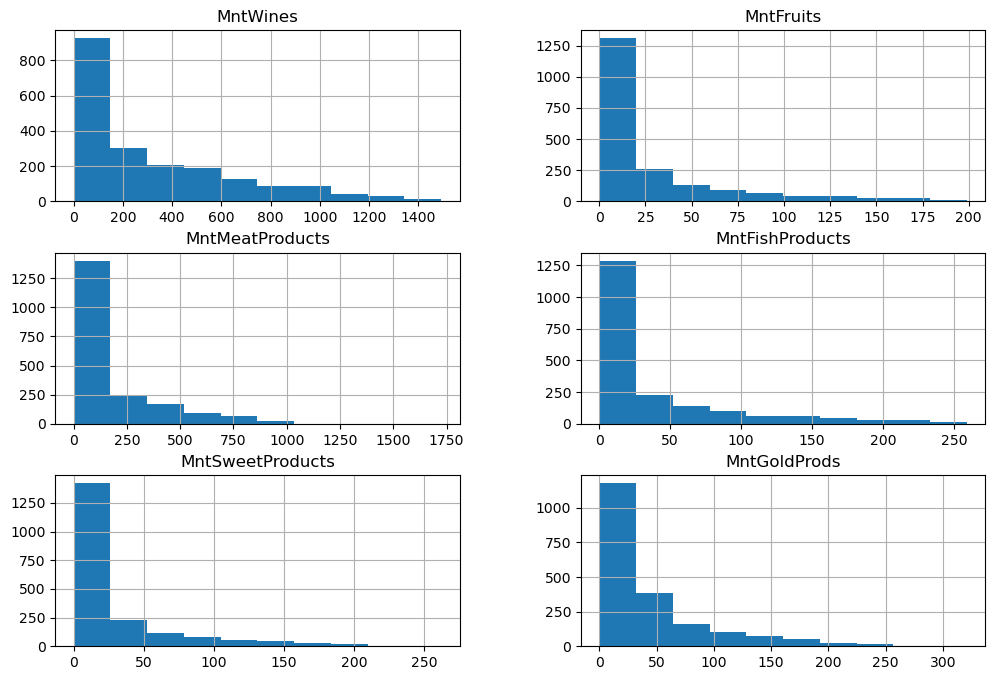

In [33]:
produtos.hist(figsize=(12,8))

As distribuições dessas variáveis são todas assimétricas, com frequência maior nos intervalos iniciais, sendo que vinho parece ser o produto mais consumido.

In [34]:
# Categorias de produtos com maiores gastos:

produtos.sum().sort_values(ascending=False)

MntWines            612771
MntMeatProducts     332598
MntGoldProds         87764
MntFishProducts      75570
MntSweetProducts     54690
MntFruits            53032
dtype: int64

Vinho é a categoria de produto com maior gasto, tendo \\$612.771,00 em compras, seguida de Carnes, com pouco mais da metade da anterior, \\$332.598,00.  
Abaixo de $100.000 de gastos em cada, vem na sequência: Produtos de Ouro, Peixes, Doces e Frutas.

#### Variável Alvo

In [35]:
# WebPurchases

compras = base['WebPurchases'].value_counts()
print(compras)

WebPurchases
1    1019
0     985
Name: count, dtype: int64


<Axes: xlabel='WebPurchases', ylabel='count'>

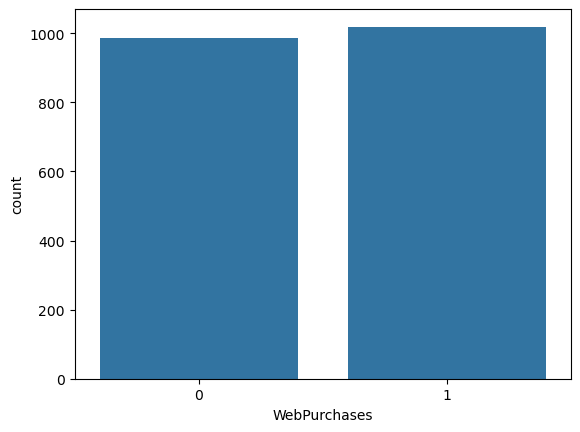

In [36]:
sns.barplot(compras)

As classes da variável alvo apresentam equilíbrio entre si, na proporção aproximadamente de 50-50. 

### 1.3 - Análise Bivariada

Nesta etapa prossigo com análises entre duas ou mais variáveis, envolvendo a variável-alvo.

#### Renda

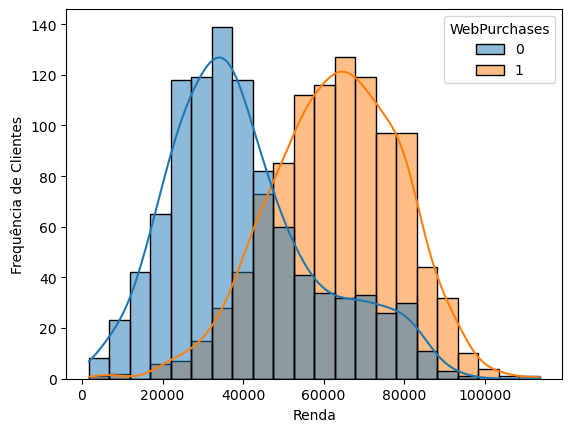

In [37]:
sns.histplot(base, x='Income', hue='WebPurchases', kde=True)
plt.xlabel('Renda')
plt.ylabel('Frequência de Clientes')
plt.show()

A primeira variável que relaciono à alvo é a de renda.  
Acima produzi um histograma que representa os clientes que compram na loja online e os que nunca compraram, pelo critério da renda.  
A altura das barras reflete a quantidade de clientes em dada faixa de renda, e as cores distinguem os que já efetuaram compras no site (laranja), e os que não o fizeram (azul).  
Nota-se uma diferença significativa, sendo a maior frequência de quem compra online nas faixas acima dos 50 mil anuais, enquanto que quem nunca comprou no site costuma ter renda de até 40 mil anuais, aproximadamente.

#### Idade

É possível que 'Year_Birth', ou idade, seja uma variável que influencie a target, pela hipótese de que pessoas mais velhas tendem a preferir fazer compras em lojas físicas e pessoas mais jovens terem a tendência de comprar mais online.

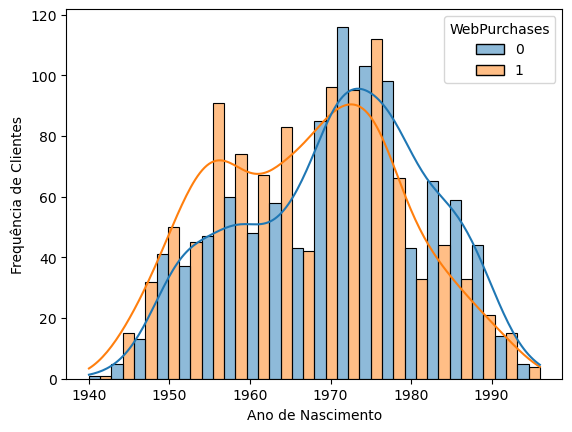

In [38]:
sns.histplot(base, x='Year_Birth', hue='WebPurchases', multiple='dodge', kde='True')
plt.xlabel('Ano de Nascimento')
plt.ylabel('Frequência de Clientes')
plt.show()

No gráfico acima fiz a opção de plotar as barras de cada classe sem sobreposição umas às outras, e acrescentei a curva de densidade para facilitar a visualização.  
Os clientes que nasceram entre 1970 e 1980 estão entre os mais frequentes, e neles se observa comportamento similar entre quem já fez compras no site e os que ainda não.  
É interessante notar que os mais novos, nascidos a partir da década de 80, ao contrário do que se supõe, tendem a comprar menos no site.  
Além disso a curva laranja sobre os intervalos correspondentes aos clientes mais velhos, nascidos até meados da década de 60, mostra que na maioria já fizeram alguma compra no site.

#### Gastos Produtos

Para facilitar a análise entre a target e as variáveis de gastos por categoria de produto, optei por plotar em conjunto, cada uma agrupada pelas classes 0 e 1 de 'WebPurchases' e verificar os grupos de produtos que se destaquem dos demais por ter proporção maior de consumidores que já tenham feito alguma compra no site.

In [39]:
produtos_grouped_web = base.groupby('WebPurchases')[['MntWines', 
                                                     'MntMeatProducts', 
                                                     'MntGoldProds',
                                                     'MntFishProducts', 
                                                     'MntSweetProducts', 
                                                     'MntFruits']].mean().reset_index()
produtos_grouped_web

,WebPurchases,MntWines,MntMeatProducts,MntGoldProds,MntFishProducts,MntSweetProducts,MntFruits
0,0,120.074112,75.354315,23.671066,19.432487,11.958376,12.633503
1,1,485.277723,253.556428,63.246320,55.376840,42.110893,39.831207


In [40]:
soma_produtos = base.groupby('WebPurchases')[['MntWines', 
                                     'MntMeatProducts', 
                                     'MntGoldProds',
                                     'MntFishProducts', 
                                     'MntSweetProducts', 
                                     'MntFruits']].sum().reset_index()
soma_produtos

,WebPurchases,MntWines,MntMeatProducts,MntGoldProds,MntFishProducts,MntSweetProducts,MntFruits
0,0,118273,74224,23316,19141,11779,12444
1,1,494498,258374,64448,56429,42911,40588


In [41]:
percentual = soma_produtos / soma_produtos.sum() * 100
percentual

,WebPurchases,MntWines,MntMeatProducts,MntGoldProds,MntFishProducts,MntSweetProducts,MntFruits
0,0.0,19.301338,22.31643,26.566702,25.328834,21.537758,23.465078
1,100.0,80.698662,77.68357,73.433298,74.671166,78.462242,76.534922


In [42]:
percentual_vendas = percentual[['MntWines', 'MntMeatProducts', 'MntGoldProds','MntFishProducts', 'MntSweetProducts', 'MntFruits']]

<Figure size 800x600 with 0 Axes>

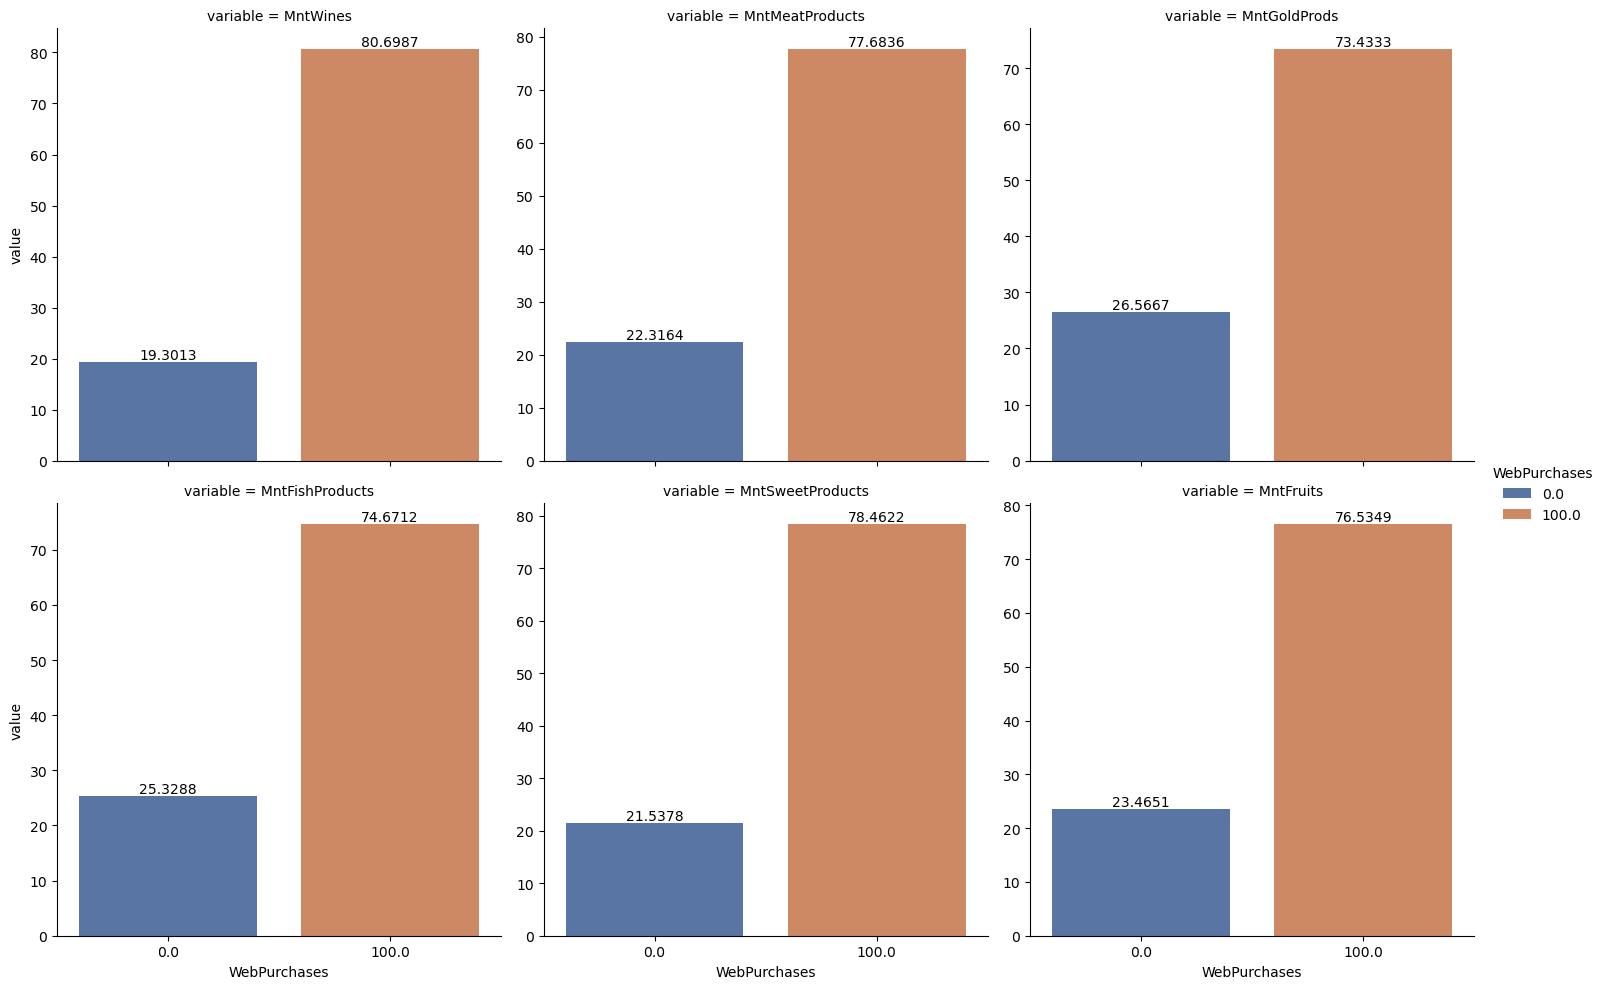

In [43]:
produtos_percentual = percentual.melt(id_vars='WebPurchases', value_vars=percentual_vendas)

plt.figure(figsize=(8, 6))

grade = sns.catplot(
        data=produtos_percentual, 
        x='WebPurchases', 
        y='value', 
        col='variable', 
        kind='bar',        
        col_wrap=3,        
        sharey=False,      
        hue='WebPurchases',
        palette='deep'
)

for ax in grade.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)

plt.show()

Com a visualização acima notamos que não há discrepâncias tão grandes entre categorias, mas é possível destacar diferenças.

A categoria de produtos que se destaca com maior número de compradores online é a de **vinhos**, com **80.7% de compradores que já efetuaram alguma compra no site**. Nesta categoria 19% nunca compraram online.  

Em segundo lugar, com 78% de clientes que já compraram no site, está a categoria de **doces**.  

Carne (77.7%), frutas (76.5%), peixe (74.7%) e produtos de ouro (73.4%) vem a seguir.  

De todo o modo, os consumidores desses produtos presentes no dataset tem uma tendência geral a comprar pelo site, tendo em vista a larga diferença na proporção entre as classes, em favor da positiva.  

Presume-se que esses produtos estejam no foco da loja para marcar presença online, possivelmente como produtos de atração de clientes que já estejam acostumados a comprar pela internet.  

Obs.: Apesar de proporcionalmente terem o mesmo comportamento em relação à variável alvo, essas features apresentam valores absolutos com grandes diferenças nas compras (conforme visto acima na tabela de produtos mais consumidos), sendo que as categorias com maiores gastos podem ter maior relevância na previsão de compra no site.

#### Compra Recente

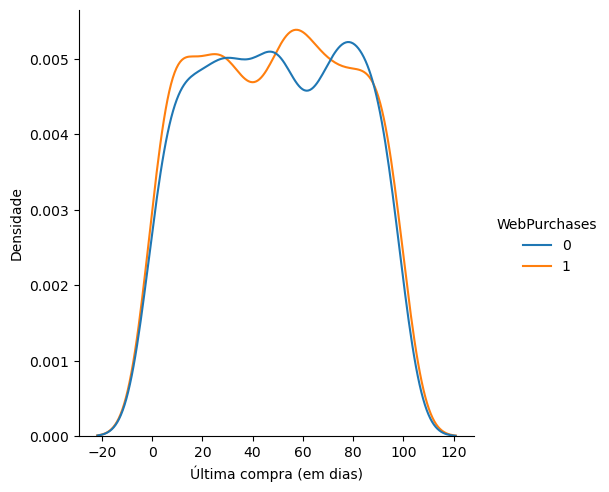

In [44]:
# Número de dias desde a última compra do cliente

sns.displot(base, x='Recency', hue='WebPurchases', kind='kde')
plt.xlabel("Última compra (em dias)")
plt.ylabel("Densidade")
plt.show()

O gráfico acima ilustra se o efeito do tempo desde a última compra reflete o fato do cliente já ter comprado online ou não. Aparentemente não há correlação forte entre as variáveis. Essa é uma visualização que mostra as densidades dessa feature na linha azul para quem nunca comprou e na laranja para quem já o fez.

#### Nº de Compras na Loja 

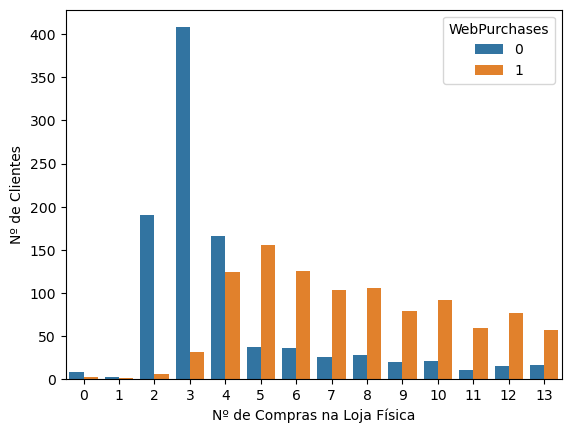

In [45]:
sns.countplot(base, x='NumStorePurchases', hue='WebPurchases')
plt.xlabel("Nº de Compras na Loja Física")
plt.ylabel("Nº de Clientes")
plt.show()

O gráfico de barras acima demonstra que quanto maior o número de compras na loja física, mais propenso fica o cliente a realizar uma compra no site. São esses os que, em maioria, tem histórico de compra no site. 
- Há registros de clientes que compram de 0 a 13 vezes ao mês;
- Quase a totalidade dos clientes compra pelo menos duas vezes ao mês na loja física;
- Apenas uma parcela dos clientes da loja física que compram acima de 5 vezes no mês nunca comprou no site;
- Os clientes que compram de 2 a 4 vezes ao mês na loja estão entre os que, em maioria, nunca fizeram compras online.
  


#### Nº de Visitas ao Site

In [46]:
# Número de visitas ao mês 

base['NumWebVisitsMonth'].unique()

array([ 7,  5,  4,  6,  8,  9, 20,  2,  3,  1, 10,  0, 14, 19, 17, 13])

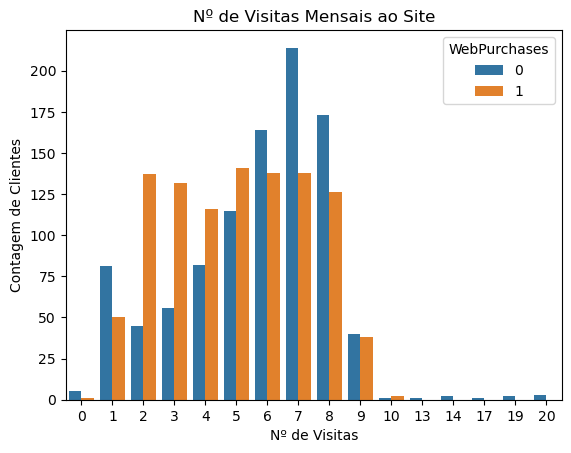

In [47]:
sns.countplot(base, x='NumWebVisitsMonth', hue='WebPurchases')
plt.title('Nº de Visitas Mensais ao Site')
plt.xlabel('Nº de Visitas')
plt.ylabel('Contagem de Clientes')
plt.show()

Este gráfico de barras mostrando o número de visitas ao site entre os clientes que já compraram e os que ainda não o fizeram, evidencia que dentre estes últimos há muitos que acessam o site até 8 vezes no mês, mas que nunca chegaram a realizar uma compra.  
- Praticamente todos os clientes da base já fizeram pelo menos uma visita ao mês no site;  
- Há uma distribuição regular de clientes que visitam o site, entre 2 a 8 vezes/mês, e já são clientes da loja online (barras laranjas);
- A quantidade de clientes que acessam o site e nunca compraram nada sobe a cada intervalo de visitas (barras azuis);
  
Tendo em vista o número elevado de clientes que fazem o acesso mas que nunca compraram, não se pode descartar a hipótese de que muitos clientes usam o site apenas para consultar os preços, mas preferem comprar na loja física, ou usam o site para comparar preços com outras lojas.

## 2 - Pré-processamento









### 2.1 - Codificação:

A seguir faço a codificação das variáveis categóricas para análise das correlações:

In [48]:
from sklearn.preprocessing import LabelEncoder

In [49]:
label_encoder = LabelEncoder()

**Education:**

In [50]:
base.Education.unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

In [51]:
base['Education'] = label_encoder.fit_transform(base['Education'])

In [52]:
base.Education.unique()

array([2, 4, 3, 1, 0])

**Estado Civil:**

In [53]:
base.Marital_Status.unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Others'],
      dtype=object)

In [54]:
base['Marital_Status'] = label_encoder.fit_transform(base['Marital_Status'])

In [55]:
base.Marital_Status.unique()

array([3, 4, 1, 0, 5, 2])

### 2.2 - Análise de Correlações:

In [56]:
base.corr()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
Year_Birth,1.000000,-0.191634,-0.029124,-0.218566,0.250682,-0.013309,-0.170600,-0.025703,-0.050519,-0.043369,-0.028341,-0.052957,-0.144601,0.128703,0.001923,-0.154109
Education,-0.191634,1.000000,-0.006114,0.139158,-0.045596,-0.001675,0.196241,-0.091658,0.032489,-0.112964,-0.110596,-0.092684,0.066535,-0.042538,-0.043271,0.090118
Marital_Status,-0.029124,-0.006114,1.000000,0.005913,-0.016012,0.020422,0.003521,0.003191,0.032833,0.044973,0.017697,0.002468,-0.008949,-0.032687,0.009230,-0.006482
Income,-0.218566,0.139158,0.005913,1.000000,-0.539429,0.003304,0.725655,0.535371,0.696952,0.549707,0.551434,0.408917,0.683412,-0.643271,-0.026687,0.559200
Kidhome,0.250682,-0.045596,-0.016012,-0.539429,1.000000,0.021076,-0.506251,-0.373624,-0.445510,-0.389449,-0.375887,-0.353169,-0.509511,0.442526,0.034472,-0.413221
Recency,-0.013309,-0.001675,0.020422,0.003304,0.021076,1.000000,0.014695,-0.013093,0.017897,-0.002299,0.023736,0.012354,0.001287,-0.011674,-0.001376,-0.002821
MntWines,-0.170600,0.196241,0.003521,0.725655,-0.506251,0.014695,1.000000,0.383479,0.588970,0.393633,0.382513,0.390354,0.635244,-0.321872,-0.035321,0.542221
MntFruits,-0.025703,-0.091658,0.003191,0.535371,-0.373624,-0.013093,0.383479,1.000000,0.565849,0.589811,0.557017,0.400338,0.454020,-0.414462,-0.000233,0.341399
MntMeatProducts,-0.050519,0.032489,0.032833,0.696952,-0.445510,0.017897,0.588970,0.565849,1.000000,0.589142,0.545648,0.371427,0.509553,-0.532024,-0.019101,0.406300
MntFishProducts,-0.043369,-0.112964,0.044973,0.549707,-0.389449,-0.002299,0.393633,0.589811,0.589142,1.000000,0.580577,0.426024,0.460659,-0.444003,-0.017113,0.327269


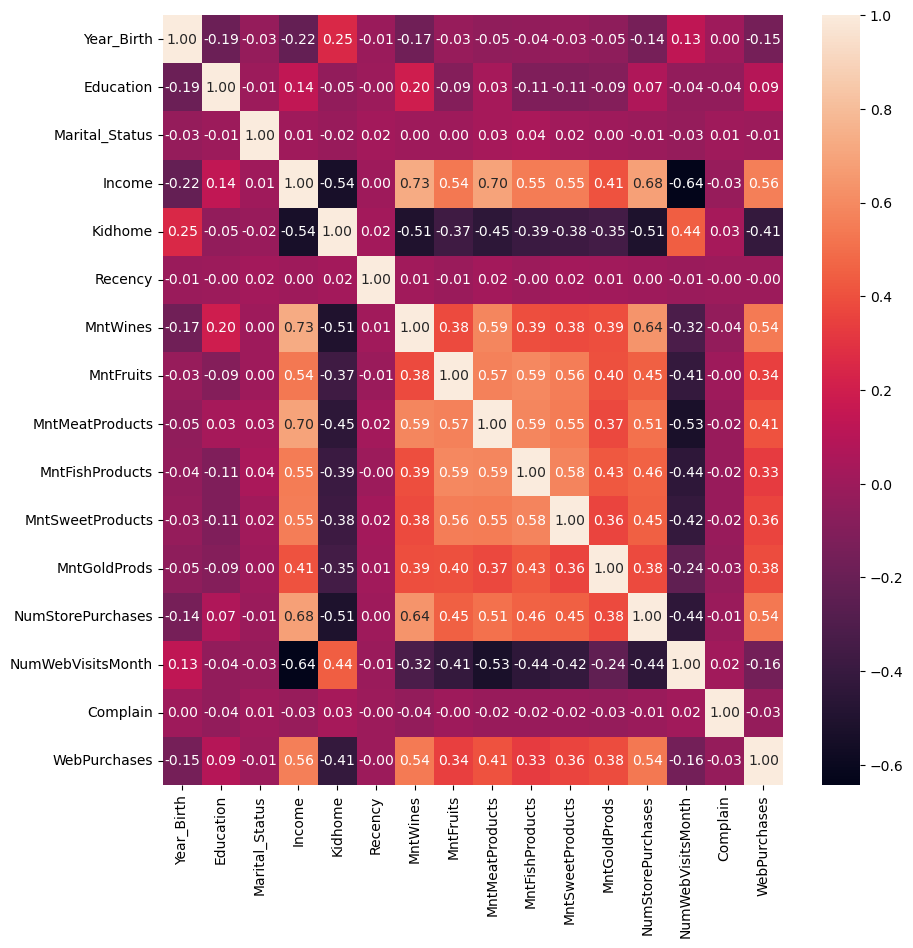

In [57]:
correlacoes = base.corr()
plt.figure(figsize=(10,10))
sns.heatmap(correlacoes, annot=True, fmt='.2f')
plt.show()

As correlações mais relevantes com a variável dependente são:  
Renda (56%)  
Gastos Vinho (54%)  
Número de Vendas Loja Física (54%)  

A seguir, com correlações relevantes também, vêm as features de categorias de produtos: Carne (41%), Ouro (38%), Doces (36%), Frutas (34%), Peixe (33%)  

Por outro lado temos variáveis pouco relevantes, com correlações próximas a zero, não só com WebPurchases, mas também com outras variáveis. São elas: Reclamações (3%), Estado Civil (1%) e Compras Recentes (0%).  

Para buscar uma simplificação do modelo, opto pela exclusão dessas variáveis:

In [58]:
base = base.drop(['Complain','Marital_Status','Recency'], axis=1)

In [59]:
base.columns

Index(['Year_Birth', 'Education', 'Income', 'Kidhome', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumStorePurchases', 'NumWebVisitsMonth',
       'WebPurchases'],
      dtype='object')

### 2.3 - Separação treino/teste:

In [60]:
X = base.drop("WebPurchases", axis=1)
y = base["WebPurchases"]

## 3 - Modelagem

Para esta base vou aplicar os modelos de **Regressão Logística** e **Random Forest**:

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [62]:
# Importação de bibliotecas para normalização dos dados e validação cruzada:

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

Configuração de Validação Cruzada para aplicação nas bases treino e teste:

In [63]:
folds = 5
cross_validation = KFold(n_splits=folds, shuffle=True, random_state=42)

Regressão Logística:

In [64]:
regressao = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
modelo_regressao = cross_val_score(regressao, X, y, cv=cross_validation)

Random Forest:

In [65]:
floresta = make_pipeline(StandardScaler(), RandomForestClassifier())
modelo_floresta = cross_val_score(floresta, X, y, cv=cross_validation)

## 4 - Avaliação


### 4.1 - Resultados:

In [66]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

**Resultados modelo Regressão Logística:**

In [67]:
print(f"Regressão Logística\n Acurácia de cada fold: \n {modelo_regressao}")
print("\n Acurácia Média:\n", modelo_regressao.mean().round(4))

Regressão Logística
 Acurácia de cada fold: 
 [0.85785536 0.8553616  0.84538653 0.83790524 0.8525    ]

 Acurácia Média:
 0.8498


**Resultados modelo Random Forest:**

In [68]:
print(f"Random Forest\n Acurácia de cada fold: \n {modelo_floresta}")
print("\n Acurácia Média:\n", modelo_floresta.mean().round(4))

Random Forest
 Acurácia de cada fold: 
 [0.89027431 0.9127182  0.90523691 0.91022444 0.9       ]

 Acurácia Média:
 0.9037


Os resultados do modelo de Floresta Aleatória são consideravelmente melhores que os do modelo de Regressão Logística, que teve acurácia média de 85%.  

A média do Random Forest foi de 90%, com os resultados de cada fold todos superiores em relação aos folds do modelo de regressão.  

A seguir prossigo com as verificações de performance dos modelos.

### 4.2 - Aplicação dos modelos sem validação cruzada:

Abaixo faço a importação da biblioteca para treinar os modelos sem validação cruzada, separando base treino e teste, para verificar seu desempenho quando aplicado à base toda.  

Também importo o métodos de relatório de classificação para conferir os resultados, e para o gráfico da matriz de confusão.

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import plotly.figure_factory as ff

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Regressão:**

In [71]:
regressao.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=1000))])

In [72]:
y_pred_regressao = regressao.predict(X_test)

In [73]:
report_regressao = classification_report(y_test, y_pred_regressao)

In [74]:
print("Relatório de Classificação:\n", report_regressao)

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.87      0.82      0.85       194
           1       0.84      0.89      0.87       207

    accuracy                           0.86       401
   macro avg       0.86      0.86      0.86       401
weighted avg       0.86      0.86      0.86       401



De acordo com o relatório acima temos um recall de 89% para a classe positiva, isto é, a cada 10 previsões para a classe 1, o modelo identifica corretamente aproximadamente em 9 vezes.  

Já para a classe 0, o modelo tem desempenho inferior, acertando apenas 82% das vezes.  

Esse modelo tende a priorizar a classe positiva, com 87% na média harmônica calculada pelo f1-score, contra 85% da classe 0.

**Random Forest:**

In [75]:
floresta.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier', RandomForestClassifier())])

In [76]:
y_pred_floresta = floresta.predict(X_test)

In [77]:
report_floresta = classification_report(y_test, y_pred_floresta)

In [78]:
print("Relatório de Classificação:\n", report_floresta)

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.94      0.82      0.88       194
           1       0.85      0.95      0.90       207

    accuracy                           0.89       401
   macro avg       0.89      0.89      0.89       401
weighted avg       0.89      0.89      0.89       401



O modelo capta bem os casos positivos, em que os clientes compram também no site, acertando 95% das vezes, segundo o recall.  

Este modelo também está com desempenho superior para previsões da classe positiva, isto é, está com a tendência de prever mais casos positivos do que negativos.  

Na aplicação à toda a base, os resultados do Random Forest são superiores aos da Regressão Logística.  

A partir daqui sigo com a exploração e busca de otimização de resultados apenas do modelo Random Forest:

**Matriz de Confusão:**

In [79]:
# Matriz de confusão com os resultados do Random Forest:

matriz = confusion_matrix(y_test, y_pred_floresta)

classes = ['0', '1']

fig = ff.create_annotated_heatmap(
    z=matriz,
    x=classes,
    y=classes,
    colorscale='Blues',
    showscale=True
)
fig.update_layout(
    title='Matriz de Confusão',
    xaxis_title='Rótulos Previstos',
    yaxis_title='Rótulos Verdadeiros',
    font=dict(
        family='Arial',
        size=12,
        color='black'
    )
)

Precisão: Analisando os dois quadrantes na vertical do lado direito da matriz, de 230 previsões totais para 'sim', o modelo acertou 196 vezes, ou seja, 85% de acerto.  

Recall: Conforme vemos pelos quadrantes superiores da matriz, dos 207 casos positivos da base de teste, o modelo acertou corretamente 196 deles, ou seja, 94% de acerto.  

Das 194 ocorrências '0', como podemos ver nos quadrantes inferiores, o modelo previu 34 deles como sendo da classe '1'.  

- É interessante notar que esses 34 clientes podem ter um perfil parecido com o de quem já é cliente do site e ações específicas poderiam ser destinadas a esse grupo.  

- Da mesma forma, os clientes corretamente identificados, como mostra o recall de 94%, podem ter seu perfil analisado para que ações de marketing sejam implementadas a grupos de potenciais clientes com comportamento semelhante.  

- Conforme visto na análise bivariada, o número de visitas ao site é alto entre quem nunca realizou compra. Apesar dessa feature não figurar como forte correlacionada à variável alvo, seria fundamental atentar para os clientes que fazem o acesso ao site para destinar a estes ações com objetivo de conversão.

### 4.3 - Importância de Features e Simplificação do modelo:

Investigação das features que o modelo de Random Forest calculou como mais importantes para as divisões dos dados.  
Em seguida, implementação do modelo somente com elas para ver a possibilidade de um resultado superior:

<Axes: >

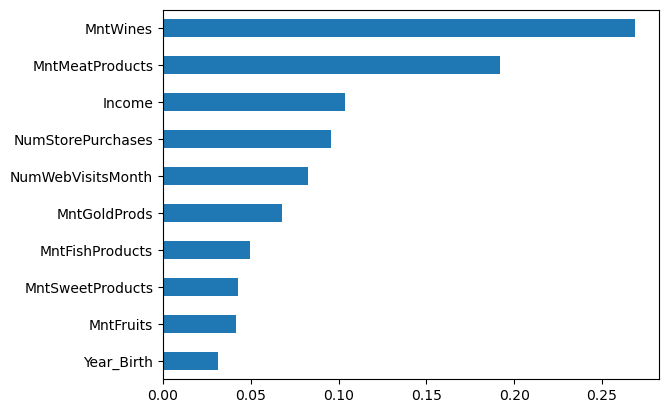

In [80]:
importances = pd.Series(floresta[-1].feature_importances_, index=X_train.columns)
importances.nlargest(10).sort_values().plot(kind='barh')

O modelo considera como as cinco mais importantes para a classificação as seguintes features:  

1ª 'Gastos com vinhos',  
2ª 'Gastos com carnes',  
3ª 'Renda',  
4ª 'Nº de compras na loja'  
5ª 'Nº de acessos mensais ao site'

A seguir, treinamento do mesmo modelo somente com estas cinco:

In [83]:
X_train_top_feat = X_train[['MntWines','MntMeatProducts','Income','NumStorePurchases','NumWebVisitsMonth']]
X_test_top_feat = X_test[['MntWines','MntMeatProducts','Income','NumStorePurchases','NumWebVisitsMonth']]

In [84]:
floresta_top_feat = RandomForestClassifier(random_state=42)

In [85]:
floresta_top_feat.fit(X_train_top_feat, y_train)

RandomForestClassifier(random_state=42)

In [86]:
previsoes_top_feat = floresta_top_feat.predict(X_test_top_feat)

In [87]:
relatorio_top_feat = classification_report(y_test, previsoes_top_feat)

In [89]:
print("Relatório de Classificação - Melhores Features:\n", relatorio_top_feat)

Relatório de Classificação - Melhores Features:
               precision    recall  f1-score   support

           0       0.93      0.85      0.88       194
           1       0.87      0.94      0.90       207

    accuracy                           0.89       401
   macro avg       0.90      0.89      0.89       401
weighted avg       0.90      0.89      0.89       401



Como vemos pelo relatório, o modelo treinado apenas com as features consideradas mais importantes não gerou resultados melhores, apenas manutenção do anterior.  

Para a classe 1 ele melhorou a precisão em 2% e para a classe 0 obteve melhora em 3% no recall.  

Contudo regrediu 1% tanto na precisão da classe 0, quanto no recall da classe 1.

A acurácia permaneceu em 89%, bem como o F1 score se manteve em 88% para a classe 0, e 90% para a classe 1.  


**Visualização:**

Abaixo treino o modelo novamente para exibir a figura de uma das árvores deste modelo de floresta, apenas com um nível de profundidade, para ilustrar a divisão dos dados da feature considerada principal dentre as cinco mais importantes:

In [81]:
from sklearn.tree import plot_tree

In [90]:
forest_depth = RandomForestClassifier(max_depth=1, random_state=42)
forest_depth.fit(X_train_top_feat, y_train)

RandomForestClassifier(max_depth=1, random_state=42)

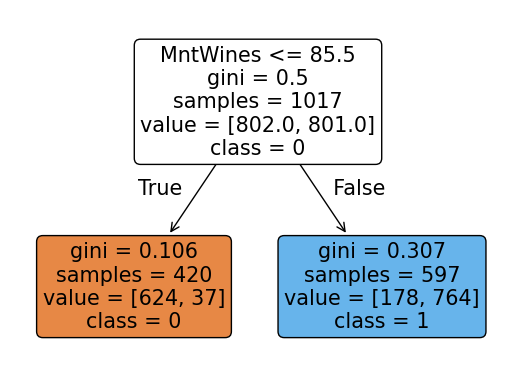

In [91]:
plot_tree(
    forest_depth.estimators_[0],
    feature_names=X_train_top_feat.columns,
    class_names=['0','1'],
    filled=True,
    rounded=True
)
plt.show()

O modelo considerou a variável de compras de vinhos como mais relevante para determinar a classificação de compra no site.  

Vemos na figura que o modelo determinou, de acordo com o critério do índice de pureza padrão, que clientes com gastos inferiores ou iguais a $85,50 em vinhos nos últimos dois anos fossem classificados como 0 (não faz compra no site).  

O índice no primeiro nó de decisão à esquerda ficou em 0.10, sendo que quanto menor, ou mais 'puro', maior a qualidade da divisão. Neste nó a árvore classifica 624 amostras como 0 e apenas 37 como 1.  

O índice do nó à direita, com amostras de clientes com gastos acima do valor estipulado, é um pouco maior, ou seja, mais incerto, mas ainda assim com redução relativa, de 0.5 para 0.3. Nesse nó, 178 clientes são classificados como '0', e 764 como '1'.

Obs.: Este é somente o primeiro nível de profundidade de uma das árvores do modelo, sendo que cada árvore pode considerar apenas algumas features.


### 4.4 - Otimização:

Abaixo prossigo com o último passo, otimizando o modelo de Random Forest buscando os melhores hiperparâmetros para ver se teremos resultados melhores.

Como o modelo de floresta não é tão sensível a dados não padronizados, vou aplicá-lo sem a normalização, assim como no treinamento anterior:

In [84]:
from sklearn.model_selection import RandomizedSearchCV

In [88]:
rf_model = RandomForestClassifier(random_state=42)

In [89]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

In [90]:
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid,
                                   n_iter=100, cv=5, n_jobs=-1, verbose=2, random_state=42, scoring='accuracy')

In [91]:
#random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, scoring='accuracy', verbose=2)

In [92]:
best_params = random_search.best_params_
print(f"Melhores Hiperparâmetros: {best_params}")

Melhores Hiperparâmetros: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': None}


In [93]:
melhor_modelo = random_search.best_estimator_
melhor_modelo.fit(X_train, y_train)

RandomForestClassifier(max_features=None, min_samples_leaf=4,
                       min_samples_split=5, n_estimators=200, random_state=42)

In [94]:
y_pred_best_params = melhor_modelo.predict(X_test)

In [95]:
relatorio_best_params = classification_report(y_test, y_pred_best_params)
print("Relatório de Classificação:\n", relatorio_best_params)

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.93      0.84      0.88       194
           1       0.86      0.94      0.90       207

    accuracy                           0.89       401
   macro avg       0.89      0.89      0.89       401
weighted avg       0.89      0.89      0.89       401



Como vemos pelo relatório acima, o treinamento do modelo com os melhores hiperparâmetros encontrados não altera significativamente os resultados.  

A acurácia, por exemplo, se mantém em 89%, bem como as demais métricas se mantém estáveis, mesmo com a otimização.  

De todo o modo, o modelo parece aprender os dados novos com eficiência, sem overfitting, e com métricas de classificação altas.  

Permanecem os insights gerados ao longo da análise, com atenção para:  
- clientes que acessam o site e não compram, possivelmente para pesquisa de preço para tomada de decisão de compra, seja na loja física, ou em concorrente;
- consumidores das categorias de vinho e carne, principalmente, que tem maior propensão a compras no site, com a possibilidade de já serem clientes habituados a comprar online;
- clientes de renda mais baixa tem menor tendência a comprar no site - ações de descontos somente pelo site ou aplicativo para esse grupo podem levar a mais acessos e conversões de vendas;
- clientes que tem histórico de mais compras na loja física tendem a fazer compras pelo site também. Isso sugere a necessidade de fidelização de clientes que compram menos, para que sejam mais frequentes e gerem mais vendas online com ações específicas para esse fim.